# Проверка логики алгоритмов в плагинах QGIS

In [1]:
import os

import osmnx as ox
import numpy as np
import pandas as pd
import geopandas as gpd
import contextily as ctx
import matplotlib.pyplot as plt
import tabulate
import contextily as ctx

# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\nContextily', ctx.__version__,
      )

ox.settings.default_access = ''

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
Contextily 1.6.2


In [2]:
DATA_NODE_FIELD     = 'node'
UNITS_NAME_FIELD    = 'name'
# Для графа:
EDGES_WEIGHT_FIELD  = 'travel_time'
## Для матрицы прибытия:
DATA_SAMPLE_SIZE    = None
DATA_CUTOFF_FIELD   = None
# TARGET_SET          = None

## Для ADD:
NAMES_PATTERN       = '{}'
START_NAMES_INDEX   = 1

## Загрузка графа дорожной сети

<Axes: >

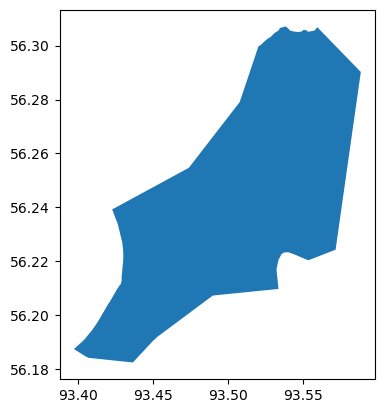

In [3]:
# Загрузка границ города
bounds = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='bounds')
bounds.plot()

In [4]:
# Загрузка графа дорог
bounds_buffer = ox.projection.project_gdf(bounds).buffer(2000)
bounds_buffer = ox.projection.project_gdf(bounds_buffer, to_latlong=True)
G = ox.graph_from_polygon(bounds_buffer.union_all(),
                            simplify         = False,
                            retain_all       = True,
                            truncate_by_edge = False,
                            network_type     = 'drive_service')

In [ ]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, figsize=(10, 10));

In [ ]:
# Сохраняем ребра графа как geopackage
ox.graph_to_gdfs(G, edges=True, nodes=False).to_file('roads_temp.gpkg', driver='GPKG');

## Служебные функции

In [ ]:
def plot_map(borders, g_nodes, best_nodes):
    ## Улучшенная печать карты
    """
    Печать карты с границами города и узлами
    """
    # Настройка стиля графика
    plt.style.use('bmh')

    fig, ax = plt.subplots(figsize=(10, 10))
    borders.plot(ax=ax, color='#fcfcd9', edgecolor='black', linewidth=2, alpha=0.7, zorder=1)

    # Отображение узлов
    g_nodes.loc[best_nodes.keys()].plot(ax=ax, facecolors='r', edgecolors='k', markersize=50, label='Размещение')

    # Подписи к узлам
    offset = (float(borders.bounds.iloc[0]['maxy']) - float(borders.bounds.iloc[0]['miny'])) / 100
    for node, unit in best_nodes.items():
        g_node_geometry = g_nodes.loc[node].geometry
        ax.text(
            g_node_geometry.x,
            g_node_geometry.y,
            str(unit),
            fontsize=10, 
            color='black',
            ha='center',
            va='bottom',
            position = (g_node_geometry.x, g_node_geometry.y + offset),
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='k', boxstyle='round,pad=0.2'),
            zorder=5
        )

    # Добавить подложку OSM
    ctx.add_basemap(ax, 
                    crs=g_nodes.crs, 
                    source=ctx.providers.OpenStreetMap.Mapnik, 
                    alpha=0.7, 
                    zorder=0)

    ax.legend(loc='upper left', fontsize=12, frameon=True)
    plt.tight_layout()
    plt.show()

## Расчеты

### Расчет с использованием оригинального графа

In [ ]:
print(f'Количество узлов в оригинальном графе - {G.number_of_nodes()}, количество ребер - {G.number_of_edges()}')

In [ ]:
cutoff = 10
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 100  # значение для остановки расчета

# 1. Загрузка данных

# Загрузка ГДС
from fire_units.metrics import CoverIndexBuildingADD
from fire_units.settings import DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, get_atm
from graphs.speeds import kmh_to_mm, set_graph_travel_times



# Установка свойств графа
G = ox.project_graph(G)
estimated_utm_crs = G.graph['crs']
print(f'Получен граф дорог с количеством узлов - {G.number_of_nodes()} и ребер {G.number_of_edges()}. СК: {estimated_utm_crs}')

# Установка времени следования по участкам дорог
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)


# Загрузка зданий
target_layer_gdf = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='buildings')
# target_layer_gdf.set_crs(crs=estimated_utm_crs, inplace=True)



target_layer_gdf = ox.projection.project_gdf(target_layer_gdf, to_crs=estimated_utm_crs)
centroids = target_layer_gdf.geometry.centroid
target_layer_gdf[DATA_NODE_FIELD] = ox.nearest_nodes(G, centroids.x, centroids.y)
print(f'Количество объектов в целевом слое - {len(target_layer_gdf)}')
if DATA_SAMPLE_SIZE:
    target_layer_gdf = target_layer_gdf.sample(DATA_SAMPLE_SIZE)
print(f'Из них в расчет взято - {len(target_layer_gdf)}')
print(f'СК слоя зданий - {target_layer_gdf.crs}')

# Загрузка существующих подразделений:
existed_units_dict = None




# 2. Расчет ADD
# Расчет матрицы прибытия
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = cutoff,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )

# 3. Сборка решения
# ================================================================================================
## Выбор метрики
metric_func  = CoverIndexBuildingADD(target_layer_gdf, ip_val=cutoff)

## Функция обратного вызова при расчете подразделений
def after_mclp_function(best_metric, dynamic_nodes, **kwargs):
    metric = round(best_metric, 2)
    print(f'Подразделений: {len(dynamic_nodes)}, Метрика: {metric}')

## Функция остановки
def stop_case (value, dynamic_nodes, **kwargs):
    if target_metric == 0:
        return len(dynamic_nodes) >= target_value
    elif target_metric == 1:
        return value >= target_value


## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = FirstArrivalUnitState(),
    matrix              = matrix,
    metric_function     = metric_func,
    ip_val              = cutoff,
    stop_case_function  = stop_case,
    names_pattern       = NAMES_PATTERN,
    start_names_index   = START_NAMES_INDEX,
    after_mclp_function = after_mclp_function,
    check_for_best_time = True,
)

# 4. Расчет
# ================================================================================================
best_nodes, best_metric = add(
    env           = G,
    dynamic_nodes = None,
    static_nodes  = existed_units_dict,
    # area          = points_mask,
)


# 5. Печать карты
g_nodes = ox.graph_to_gdfs(G, edges=False)
plot_map(bounds, ox.projection.project_gdf(g_nodes, to_latlong=True), best_nodes)




### Расчет с использованием восстановленного графа

In [ ]:
cutoff = 10
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 100  # значение для остановки расчета

from graphs.algorithms import graph_rise_from_gpkg

# 1. Загрузка данных

# Загрузка ГДС
from fire_units.metrics import CoverIndexBuildingADD
from fire_units.settings import DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, get_atm
from graphs.speeds import kmh_to_mm, set_graph_travel_times


# Воссоздание графа с расчетом времени проезда
roads_gdf = gpd.read_file('roads_temp.gpkg')
## Проверяем наличие нужных полей
columns_list = ['highway', 'oneway', 'lanes']
for col in columns_list:
    if not col in roads_gdf.columns:
        print(f'Поле {col} отсутствует в списке полей входящего слоя дорожной сети!')
## Получаем все поля из слоя дорог, за исключением полей 'geometry' и полей ключей
## ВАЖНО! Также удаляем поле 'length', так как оно пересчитывается в функции graph_rise_from_gpkg
key_fields = ['u', 'v', 'key', 'geometry', 'osmid', 'length']
columns_list = [col for col in roads_gdf.columns if col not in key_fields]

## Реконструкция графа
G = graph_rise_from_gpkg(roads_gdf,
                        columns_list = columns_list)

## Установка свойств графа
G = ox.project_graph(G)
estimated_utm_crs = G.graph['crs']
print(f'Получен граф дорог с количеством узлов - {G.number_of_nodes()} и ребер {G.number_of_edges()}. СК: {estimated_utm_crs}')

# Установка времени следования по участкам дорог
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)





# Загрузка зданий
target_layer_gdf = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='buildings')
# target_layer_gdf.set_crs(crs=estimated_utm_crs, inplace=True)
target_layer_gdf = ox.projection.project_gdf(target_layer_gdf, to_crs=estimated_utm_crs)
centroids = target_layer_gdf.geometry.centroid
target_layer_gdf[DATA_NODE_FIELD] = ox.nearest_nodes(G, centroids.x, centroids.y)
print(f'Количество объектов в целевом слое - {len(target_layer_gdf)}')
if DATA_SAMPLE_SIZE:
    target_layer_gdf = target_layer_gdf.sample(DATA_SAMPLE_SIZE)
print(f'Из них в расчет взято - {len(target_layer_gdf)}')
print(f'СК слоя зданий - {target_layer_gdf.crs}')

# Загрузка существующих подразделений:
existed_units_dict = None




# 2. Расчет ADD
# Расчет матрицы прибытия
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = cutoff,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )

# 3. Сборка решения
# ================================================================================================
## Выбор метрики
metric_func  = CoverIndexBuildingADD(target_layer_gdf, ip_val=cutoff)

## Функция обратного вызова при расчете подразделений
def after_mclp_function(best_metric, dynamic_nodes, **kwargs):
    metric = round(best_metric, 2)
    print(f'Подразделений: {len(dynamic_nodes)}, Метрика: {metric}')

## Функция остановки
def stop_case (value, dynamic_nodes, **kwargs):
    if target_metric == 0:
        return len(dynamic_nodes) >= target_value
    elif target_metric == 1:
        return value >= target_value


## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = FirstArrivalUnitState(),
    matrix              = matrix,
    metric_function     = metric_func,
    ip_val              = cutoff,
    stop_case_function  = stop_case,
    names_pattern       = NAMES_PATTERN,
    start_names_index   = START_NAMES_INDEX,
    after_mclp_function = after_mclp_function,
    check_for_best_time = True,
)

# 4. Расчет
# ================================================================================================
best_nodes, best_metric = add(
    env           = G,
    dynamic_nodes = None,
    static_nodes  = existed_units_dict,
    # area          = points_mask,
)


# 5. Печать карты
g_nodes = ox.graph_to_gdfs(G, edges=False)
plot_map(bounds, ox.projection.project_gdf(g_nodes, to_latlong=True), best_nodes)




# Проверка объединения результирующего слоя и матрицы прибытия

In [58]:
cutoff = 10
target_set = None
target_metric = 1  # 0 - по кол-ву подразделений, 1 - по ИП 
target_value = 100  # значение для остановки расчета
data_smple_size = 100

from graphs.algorithms import graph_rise_from_gpkg

# 1. Загрузка данных

# Загрузка ГДС
from fire_units.metrics import CoverIndexBuildingADD
from fire_units.settings import DEFAULT_SPEEDS
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, get_atm
from graphs.speeds import kmh_to_mm, set_graph_travel_times



# Воссоздание графа с расчетом времени проезда
roads_gdf = gpd.read_file('roads_temp.gpkg')
## Проверяем наличие нужных полей
columns_list = ['highway', 'oneway', 'lanes']
for col in columns_list:
    if not col in roads_gdf.columns:
        print(f'Поле {col} отсутствует в списке полей входящего слоя дорожной сети!')
## Получаем все поля из слоя дорог, за исключением полей 'geometry' и полей ключей
## ВАЖНО! Также удаляем поле 'length', так как оно пересчитывается в функции graph_rise_from_gpkg
key_fields = ['u', 'v', 'key', 'geometry', 'osmid', 'length']
columns_list = [col for col in roads_gdf.columns if col not in key_fields]

## Реконструкция графа
G = graph_rise_from_gpkg(roads_gdf,
                        columns_list = columns_list)

## Установка свойств графа
G = ox.project_graph(G)
estimated_utm_crs = G.graph['crs']
print(f'Получен граф дорог с количеством узлов - {G.number_of_nodes()} и ребер {G.number_of_edges()}. СК: {estimated_utm_crs}')

# Установка времени следования по участкам дорог
set_graph_travel_times(G, DEFAULT_SPEEDS, kmh_to_mm)





# Загрузка зданий
# target_layer_gdf = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='buildings')
target_layer_gdf = gpd.read_file('G:/QGIS/Железногорск/data/Железногорск.gpkg', layer='buildings').set_index('id')
# target_layer_gdf.set_crs(crs=estimated_utm_crs, inplace=True)
target_layer_gdf = ox.projection.project_gdf(target_layer_gdf, to_crs=estimated_utm_crs)
centroids = target_layer_gdf.geometry.centroid
target_layer_gdf[DATA_NODE_FIELD] = ox.nearest_nodes(G, centroids.x, centroids.y)
print(f'Количество объектов в целевом слое - {len(target_layer_gdf)}')
if data_smple_size:
    target_layer_gdf = target_layer_gdf.sample(data_smple_size)
print(f'Из них в расчет взято - {len(target_layer_gdf)}')
print(f'СК слоя зданий - {target_layer_gdf.crs}')

# Загрузка существующих подразделений:
existed_units_dict = None




# 2. Расчет ADD
# Расчет матрицы прибытия
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = cutoff,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )

# Вариант №1
# Объединение матрицы прибытия с исходным слоем
target_layer_gdf = target_layer_gdf.merge(matrix, left_index=True, right_index=True, how='left')
target_layer_gdf

# # Вариант №2 - сохранение инвертированной матрицы в узлах ГДС
# matrix = matrix.T
# g_nodes = ox.graph_to_gdfs(G, edges=False)
# matrix = matrix.merge(g_nodes.geometry, left_index=True, right_index=True, how='left')   #.fillna(0).astype(int)



Получен граф дорог с количеством узлов - 11917 и ребер 50102. СК: EPSG:32646
Количество объектов в целевом слое - 3041
Из них в расчет взято - 100
СК слоя зданий - EPSG:32646
|########################################| 100.0%


,building,name,amenity,addr:street,building:flats,addr:housenumber,building:levels,geometry,node,0,...,11907,11908,11909,11910,11911,11912,11913,11914,11915,11916
id,,,,,,,,,,,,,,,,,,,,,
55554611,apartments,None,None,улица 60 лет ВЛКСМ,None,22,9,"MULTIPOLYGON (((532935.488 6231596.952, 532937...",985,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.736408,7.857247,NaN
188083595,yes,None,None,Школьная улица,None,52В,None,"MULTIPOLYGON (((532570.097 6234842.784, 532566...",4831,5.670577,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1389248862,garages,None,None,None,None,None,None,"MULTIPOLYGON (((530230.424 6231883.394, 530201...",11882,8.475491,...,9.674807,9.646802,9.784792,9.809344,NaN,NaN,NaN,NaN,NaN,NaN
391187407,yes,None,None,Поселковая улица,None,64А,None,"MULTIPOLYGON (((526863.117 6227686.841, 526870...",6912,NaN,...,7.225171,7.197166,7.607449,7.632001,NaN,NaN,7.711269,NaN,NaN,NaN
188750563,house,None,None,Госпитальная улица,None,26,None,"MULTIPOLYGON (((527563.497 6227749.218, 527570...",8264,NaN,...,4.141294,4.169299,3.988382,4.012934,NaN,NaN,4.411069,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391222158,yes,None,None,улица Щетинкина,None,36,None,"MULTIPOLYGON (((527719.633 6227486.714, 527713...",5934,NaN,...,4.714049,4.742055,4.561137,4.585689,NaN,NaN,3.313010,NaN,NaN,NaN
123373178,yes,None,None,Школьная улица,None,31,4,"MULTIPOLYGON (((532689.363 6234028.463, 532687...",4497,3.178738,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.430355,8.551194,NaN
202065063,house,None,None,улица Горького,None,40,None,"MULTIPOLYGON (((533779.444 6234799.779, 533792...",9754,6.209318,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.492786,9.613624,NaN


In [59]:
matrix

,0,1,2,3,4,5,6,7,8,9,...,11907,11908,11909,11910,11911,11912,11913,11914,11915,11916
55554611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.736408,7.857247,NaN
188083595,5.670577,5.734011,5.604567,5.981046,6.212242,6.334355,6.670257,6.794072,6.879941,6.952144,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1389248862,8.475491,8.412057,8.541502,8.165022,7.933826,7.811713,7.475811,7.351996,7.266127,7.193925,...,9.674807,9.646802,9.784792,9.809344,NaN,NaN,NaN,NaN,NaN,NaN
391187407,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,7.225171,7.197166,7.607449,7.632001,NaN,NaN,7.711269,NaN,NaN,NaN
188750563,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.141294,4.169299,3.988382,4.012934,NaN,NaN,4.411069,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
391222158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,4.714049,4.742055,4.561137,4.585689,NaN,NaN,3.313010,NaN,NaN,NaN
123373178,3.178738,3.242172,3.112728,3.489207,3.720403,3.842516,4.178418,4.302233,4.388102,4.460305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.430355,8.551194,NaN
202065063,6.209318,6.272752,6.143308,6.519787,6.750983,6.873096,7.208998,7.332813,7.418682,7.490885,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9.492786,9.613624,NaN
154729996,4.433129,4.496564,4.367119,4.743599,4.974795,5.096908,5.432810,5.556625,5.642494,5.714696,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.811499,8.932337,NaN


In [60]:
matrix.columns

Index([    0,     1,     2,     3,     4,     5,     6,     7,     8,     9,
       ...
       11907, 11908, 11909, 11910, 11911, 11912, 11913, 11914, 11915, 11916],
      dtype='int64', length=11265)

In [43]:
target_layer_gdf

,building,name,amenity,addr:street,building:flats,addr:housenumber,building:levels,geometry,node,290699819,...,13069309187,13069309188,13069309189,13069309190,13069309191,13069309192,13069309193,13069309194,13069309195,13114444371
id,,,,,,,,,,,,,,,,,,,,,
91752657,yes,Городская аптека №2,pharmacy,проспект Курчатова,None,14,1,"MULTIPOLYGON (((533588.77 6232977.318, 533586....",1841128485,4.626964,...,9.787421,9.717452,9.659350,9.636448,9.596475,9.474648,9.376756,9.695284,9.612277,NaN
352126598,yes,None,None,Кедровая улица,None,5,None,"MULTIPOLYGON (((534125.364 6235244.754, 534139...",1992134944,7.916838,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
91421779,apartments,None,None,Восточная улица,None,37,9,"MULTIPOLYGON (((534588.789 6232344.216, 534573...",3370592091,7.835412,...,9.425875,9.355906,9.297804,9.274902,9.234929,9.113102,9.015210,9.333738,9.250731,NaN
91421798,apartments,None,None,Восточная улица,None,45,9,"MULTIPOLYGON (((534502.569 6232229.262, 534487...",1063537764,8.210819,...,8.961058,8.891089,8.832987,8.810085,8.770112,8.648285,8.550393,8.868921,8.785914,9.888199
188034691,retail,Магазин №11,None,Ленинградский проспект,None,13А,1,"MULTIPOLYGON (((533186.612 6231326.25, 533187....",698276809,8.586932,...,9.916879,9.846911,9.788808,9.765906,9.725934,9.604106,9.506214,9.824742,9.741736,6.295191
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180560268,school,Железногорская «Санаторная школа-интернат»,school,улица Горького,None,46А,None,"MULTIPOLYGON (((533810.386 6234605.671, 533817...",3309724085,7.127793,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1212408849,detached,None,None,Горный проезд,None,18,None,"MULTIPOLYGON (((535101.448 6231435.458, 535113...",11233034762,NaN,...,6.629174,6.559205,6.501103,6.478201,6.438228,6.316401,6.218509,6.537037,6.454030,NaN
159327143,yes,None,None,улица Свердлова,None,33,5,"MULTIPOLYGON (((533263.823 6234432.692, 533278...",2546501365,4.797229,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

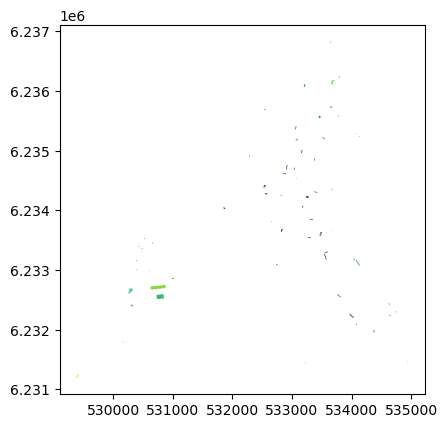

In [54]:
target_layer_gdf[[290699819, 'geometry']].plot(column=290699819)

In [ ]:
target_layer_gdf.columns = [
    f"f_{col}" if str(col)[0].isdigit() else str(col)
    for col in target_layer_gdf.columns
]
target_layer_gdf.to_file('buildings_with_atm.gpkg', driver='GPKG')

In [57]:
target_layer_gdf.shape

(100, 11321)

<span style="color:red">Увы, нельзя сохранить файл Geopackage со слишком большим количеством полей</span>

# Тесты

In [ ]:
matrix = get_atm(G,
                 data              = target_layer_gdf,
                 # data_sample_size  = DATA_SAMPLE_SIZE,
                 data_node_field   = DATA_NODE_FIELD,
                 weight            = EDGES_WEIGHT_FIELD,
                 cutoff            = 10,
                 data_cutoff_field = DATA_CUTOFF_FIELD,
                 target_set        = target_set,
                 print_calc_states = True,
                 )
matrix

In [ ]:
ox.plot_graph(G, node_size=0, edge_linewidth=0.2, figsize=(10, 10))

In [ ]:
times, _ = FirstArrivalUnitState()(G, [10])
times

In [ ]:
g_nodes = ox.graph_to_gdfs(G, edges=False)
g_nodes['arrival_time'] = times
g_nodes

In [ ]:
g_nodes.plot(column='arrival_time', figsize=(10, 10), markersize=5, legend=True)

In [ ]:
ox.graph_to_gdfs(G, nodes=False)